# CFUR: Counterfactual Fusion-Utility Routing for Resource-Aware Multimodal Fake-News Detection

**Purpose:** turn the previous static fusion comparison into a conditional-computation experiment suitable for a stronger Q1 resubmission.

### Core idea
1. Run a relatively cheaper **CLIP** branch for every sample.
2. Train an interaction-based **CLIP + ViLT** deep branch.
3. On a held-out router-training subset, measure the *counterfactual utility* of deep fusion:

   **utility = cheap classification loss − deep classification loss**

4. Train a lightweight router to predict this utility from cheap CLIP features and uncertainty signals.
5. At inference, execute ViLT only when predicted utility is above a threshold.
6. Sweep the threshold to obtain an **accuracy/F1 vs. compute Pareto curve**.

The notebook reports measured results only. It does not hard-code expected performance.

In [1]:
# Kaggle setup
# Internet must be enabled for the first model download.
#
# Pillow 12.0.0/12.1.0 shipped a broken ImageText module
# (ImportError: cannot import name '_Ink' from 'PIL._typing'), fixed in 12.2.0.
# Pinning the version alone is not enough on Kaggle: the base image already has
# an older PIL/torchvision loaded into the running kernel before this cell
# executes, so pip installing a newer Pillow here has no effect until the
# kernel actually restarts and re-imports it. This cell installs the pinned
# deps once, then force-restarts the kernel so the next run picks them up.
# First run: this cell will kill the kernel on purpose — that is expected.
# Click 'Run All' again (or just re-run cells from here) and it will skip
# straight to the else-branch below.
import os

_FLAG = "/kaggle/working/.cfur_deps_installed"

if not os.path.exists(_FLAG):
    get_ipython().system('pip -q install -U "transformers>=5.0,<6" accelerate safetensors scikit-learn pandas "pillow>=12.2.0" tqdm psutil')
    with open(_FLAG, "w") as f:
        f.write("ok")
    print("Dependencies installed with a safe Pillow pin. Restarting the kernel now — "
          "re-run this cell (or Run All) once more to continue.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed in this session — continuing.")


Dependencies already installed in this session — continuing.


In [2]:
import os, gc, time, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
# =========================
# CONFIGURATION
# =========================
SEED = 42

# Start False to verify the notebook. Switch True for manuscript runs.
FULL_PAPER_MODE = False
PAPER_SEEDS = [13, 37, 71, 101, 202] if FULL_PAPER_MODE else [13]

# Recommended: a CSV with columns text,image_path,label,split
# split values: train / val / test
MANIFEST_CSV = ""

# If MANIFEST_CSV is empty, auto-detect standard Fakeddit TSV files.
FAKEDDIT_LABEL_COL = "2_way_label"  # use "6_way_label" for fine-grained experiment
TEXT_COL_CANDIDATES = ["clean_title", "title", "text"]
ID_COL_CANDIDATES = ["id", "submission_id"]

# First verification run. Set to None for final full experiment.
MAX_TRAIN = None if FULL_PAPER_MODE else 30000
MAX_VAL   = None if FULL_PAPER_MODE else 5000
MAX_TEST  = None if FULL_PAPER_MODE else 5000

CLIP_NAME = "openai/clip-vit-base-patch32"
VILT_NAME = "dandelin/vilt-b32-mlm"

BATCH_CLIP = 32
BATCH_VILT = 16
HEAD_BATCH = 512

HEAD_EPOCHS = 30
ROUTER_EPOCHS = 35
PATIENCE = 5
LR_HEAD = 1e-3
LR_ROUTER = 8e-4
WEIGHT_DECAY = 1e-4

# Reserve this fraction of train for learning utility; classifier heads never see it.
ROUTER_HOLDOUT = 0.15

# Deployment budget: maximum fraction of samples allowed to execute ViLT.
TARGET_DEEP_RATE = 0.35

N_BOOT = 1000 if FULL_PAPER_MODE else 300

OUT_DIR = Path("/kaggle/working/cfur_outputs")
CACHE_DIR = Path("/kaggle/working/cfur_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Fallback for when the attached Kaggle dataset has TSV metadata but no image files
# (e.g. vanshikavmittal/fakeddit-dataset ships multimodal_only_samples/*.tsv only).
# Only kicks in if build_image_index() finds zero local images; the local-scan path
# above is unchanged and still tried first.
ALLOW_IMAGE_URL_FALLBACK = True
FAKEDDIT_IMAGE_URL_CANDIDATES = ["image_url", "img_url"]
IMAGE_DOWNLOAD_DIR = CACHE_DIR / "fakeddit_images"
IMAGE_DOWNLOAD_WORKERS = 24
IMAGE_DOWNLOAD_TIMEOUT = 8
IMAGE_DOWNLOAD_OVERSAMPLE = 1.3  # fetch a few extra rows per split to absorb dead links
IMAGE_DOWNLOAD_FULL_MODE_CAP = 50000  # safety cap per split when MAX_* is None (FULL_PAPER_MODE)
IMAGE_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)
print("Outputs:", OUT_DIR)

Outputs: /kaggle/working/cfur_outputs


## Data contract

Preferred input: `manifest.csv`

| text | image_path | label | split |
|---|---|---:|---|
| headline | /kaggle/input/.../abc.jpg | 0 | train |
| headline | /kaggle/input/.../xyz.jpg | 1 | val |

If no manifest is supplied, the notebook attempts to detect Fakeddit multimodal TSV files and match image filenames by sample ID.

In [4]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of {candidates} found. Columns={list(df.columns)[:30]}")

def sample_if_needed(df, n, seed=42):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(
            df, test_size=n, stratify=df["label"], random_state=seed
        )
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)

def build_image_index(root="/kaggle/input"):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    index = {}
    print("Indexing images under", root)
    for p in tqdm(Path(root).rglob("*"), desc="image index"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.stem, str(p))
    print("Indexed", len(index), "unique image stems")
    if len(index) == 0:
        print("WARNING: no image files with extensions", exts, "found anywhere under", root)
        print("Top-level contents of", root, ":", [str(x) for x in Path(root).glob("*")][:20])
    else:
        print("Example image stems:", list(index.keys())[:5])
    return index

def subsample_raw(df, n, label_col, seed=42):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(
            df, test_size=n, stratify=df[label_col], random_state=seed
        )
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)

def download_images_from_urls(df, url_col, id_col, out_dir, workers=24, timeout=8):
    try:
        import requests
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests"], check=True)
        import requests
    from concurrent.futures import ThreadPoolExecutor, as_completed

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    def _fetch(sid, url):
        sid = str(sid)
        if not isinstance(url, str) or not url.startswith("http"):
            return sid, None
        ext = os.path.splitext(url.split("?")[0])[1].lower()
        if ext not in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}:
            ext = ".jpg"
        dest = out_dir / f"{sid}{ext}"
        if dest.exists() and dest.stat().st_size > 0:
            return sid, str(dest)
        try:
            r = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
            if r.status_code == 200 and r.content:
                with open(dest, "wb") as f:
                    f.write(r.content)
                return sid, str(dest)
        except Exception:
            pass
        return sid, None

    pairs = list(zip(df[id_col].astype(str), df[url_col]))
    results = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_fetch, sid, url) for sid, url in pairs]
        for fut in tqdm(as_completed(futs), total=len(futs), desc="downloading images"):
            sid, path = fut.result()
            if path:
                results[sid] = path
    print(f"Downloaded {len(results)}/{len(pairs)} images successfully "
          f"({len(pairs) - len(results)} failed/dead links -- expected for older Reddit-hosted URLs).")
    return results

def pick_fakeddit_files():
    files = list(Path("/kaggle/input").rglob("*.tsv"))
    def choose(words):
        cands = []
        for p in files:
            s = p.name.lower()
            if "multimodal" in s and any(w in s for w in words):
                cands.append(p)
        return sorted(cands, key=lambda x: len(str(x)))[0] if cands else None
    return choose(["train"]), choose(["validate", "validation", "val"]), choose(["test_public", "test"])

def standardize_fakeddit(df, split_name, image_index):
    text_col = first_existing_col(df, TEXT_COL_CANDIDATES)
    id_col = first_existing_col(df, ID_COL_CANDIDATES)
    if FAKEDDIT_LABEL_COL not in df.columns:
        raise ValueError(
            f"{FAKEDDIT_LABEL_COL} not found. Label-like columns: "
            f"{[c for c in df.columns if 'label' in c.lower()]}"
        )
    out = pd.DataFrame({
        "text": df[text_col].fillna("").astype(str),
        "sample_id": df[id_col].astype(str),
        "label": df[FAKEDDIT_LABEL_COL],
        "split": split_name
    })
    out["image_path"] = out["sample_id"].map(image_index)
    _matched = out["image_path"].notna().sum()
    print(f"[{split_name}] sample_id -> image match: {_matched}/{len(out)}")
    if _matched == 0 and len(out) > 0:
        print(f"[{split_name}] example sample_ids from TSV:", out["sample_id"].head(5).tolist())
        print(f"[{split_name}] example indexed image stems:", list(image_index.keys())[:5])
    out = out.dropna(subset=["image_path", "label"])
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    return out[["text", "image_path", "label", "split"]]

def load_manifest():
    if MANIFEST_CSV:
        m = pd.read_csv(MANIFEST_CSV)
        required = {"text", "image_path", "label", "split"}
        missing = required - set(m.columns)
        if missing:
            raise ValueError(f"Manifest missing: {missing}")
        m["split"] = m["split"].astype(str).str.lower().replace(
            {"validation": "val", "valid": "val"}
        )
        return m

    train_p, val_p, test_p = pick_fakeddit_files()
    print("Detected TSVs:", train_p, val_p, test_p)
    if not all([train_p, val_p, test_p]):
        raise FileNotFoundError(
            "Could not auto-detect Fakeddit TSVs. "
            "Create manifest.csv with text,image_path,label,split and set MANIFEST_CSV."
        )
    train_raw = pd.read_csv(train_p, sep="\t")
    val_raw   = pd.read_csv(val_p, sep="\t")
    test_raw  = pd.read_csv(test_p, sep="\t")

    image_index = build_image_index("/kaggle/input")

    if len(image_index) == 0 and ALLOW_IMAGE_URL_FALLBACK:
        print("No local image files found -- falling back to downloading images from the "
              "TSVs' image_url column. Only the rows we actually need are fetched (bounded "
              "by MAX_TRAIN/MAX_VAL/MAX_TEST), not the full dataset.")
        url_col = first_existing_col(train_raw, FAKEDDIT_IMAGE_URL_CANDIDATES)
        id_col = first_existing_col(train_raw, ID_COL_CANDIDATES)

        def _bounded_cap(cap, split_name):
            if cap is not None:
                return int(cap * IMAGE_DOWNLOAD_OVERSAMPLE)
            print(f"MAX_{split_name.upper()} is None (full-dataset mode) -- capping the "
                  f"download fallback at {IMAGE_DOWNLOAD_FULL_MODE_CAP} rows for this split "
                  f"instead of attempting to fetch the entire Fakeddit image set. Attach a "
                  f"pre-downloaded image dataset if you need the full set.")
            return IMAGE_DOWNLOAD_FULL_MODE_CAP

        train_raw = subsample_raw(train_raw, _bounded_cap(MAX_TRAIN, "train"), FAKEDDIT_LABEL_COL, SEED)
        val_raw   = subsample_raw(val_raw,   _bounded_cap(MAX_VAL, "val"),     FAKEDDIT_LABEL_COL, SEED)
        test_raw  = subsample_raw(test_raw,  _bounded_cap(MAX_TEST, "test"),   FAKEDDIT_LABEL_COL, SEED)

        image_index = {}
        for name, raw in [("train", train_raw), ("val", val_raw), ("test", test_raw)]:
            print(f"Downloading images for {name} split ({len(raw)} rows)...")
            image_index.update(
                download_images_from_urls(raw, url_col, id_col, IMAGE_DOWNLOAD_DIR,
                                           workers=IMAGE_DOWNLOAD_WORKERS,
                                           timeout=IMAGE_DOWNLOAD_TIMEOUT)
            )
        print(f"Image cache ready: {len(image_index)} images in {IMAGE_DOWNLOAD_DIR}")

    return pd.concat([
        standardize_fakeddit(train_raw, "train", image_index),
        standardize_fakeddit(val_raw, "val", image_index),
        standardize_fakeddit(test_raw, "test", image_index),
    ], ignore_index=True)

manifest = load_manifest()

# --- Diagnostics: pin down exactly what came back before anything touches it ---
manifest.columns = manifest.columns.str.strip()  # guard against stray whitespace in headers
print("load_manifest() returned", len(manifest), "rows with columns:", manifest.columns.tolist())
_required_cols = {"text", "image_path", "label", "split"}
_missing_cols = _required_cols - set(manifest.columns)
if _missing_cols:
    raise KeyError(
        f"manifest is missing required column(s) {sorted(_missing_cols)} right after load_manifest(). "
        f"Columns actually present: {manifest.columns.tolist()}. "
        f"Check MANIFEST_CSV (='{MANIFEST_CSV}'), FAKEDDIT_LABEL_COL (='{FAKEDDIT_LABEL_COL}'), "
        f"and the 'Detected TSVs:' line printed above for which files were auto-matched."
    )
if len(manifest) == 0:
    raise ValueError(
        "manifest has the right columns but 0 rows after load_manifest() -- "
        "no text/image pairs were matched. Check that image_index picked up files under /kaggle/input "
        "and that sample IDs in the TSVs match image filenames."
    )

manifest = manifest.dropna(subset=["text", "image_path", "label", "split"]).copy()
manifest = manifest[manifest["image_path"].map(os.path.exists)].reset_index(drop=True)
if len(manifest) == 0:
    raise ValueError(
        "manifest has 0 rows after filtering to image_path that exist on disk -- "
        "the image_index built from /kaggle/input likely does not match the paths in image_path. "
        "Re-check build_image_index() root and the dataset's actual folder layout."
    )

le = LabelEncoder()
manifest["label_raw"] = manifest["label"]
manifest["label"] = le.fit_transform(manifest["label"].astype(str))
NUM_CLASSES = len(le.classes_)

train_df = sample_if_needed(manifest[manifest.split=="train"].copy(), MAX_TRAIN, SEED)
val_df   = sample_if_needed(manifest[manifest.split=="val"].copy(),   MAX_VAL, SEED)
test_df  = sample_if_needed(manifest[manifest.split=="test"].copy(),  MAX_TEST, SEED)

print("Classes:", dict(enumerate(le.classes_)))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
display(train_df.head())
display(pd.crosstab(train_df["label"], columns="count"))

Detected TSVs: /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv
Indexing images under /kaggle/input


image index: 0it [00:00, ?it/s]

Indexed 0 unique image stems
Top-level contents of /kaggle/input : ['/kaggle/input/datasets']
No local image files found -- falling back to downloading images from the TSVs' image_url column. Only the rows we actually need are fetched (bounded by MAX_TRAIN/MAX_VAL/MAX_TEST), not the full dataset.


downloading images:   0%|          | 0/39000 [00:00<?, ?it/s]

Downloaded 23237/39000 images successfully (15763 failed/dead links -- expected for older Reddit-hosted URLs).


...

Downloaded 3712/6500 images successfully (2788 failed/dead links -- expected for older Reddit-hosted URLs).


downloading images:   0%|          | 0/6500 [00:00<?, ?it/s]

Downloaded 3694/6500 images successfully (2806 failed/dead links -- expected for older Reddit-hosted URLs).
Image cache ready: 30643 images in /kaggle/working/cfur_cache/fakeddit_images
[train] sample_id -> image match: 23237/39000
[val] sample_id -> image match: 3712/6500
[test] sample_id -> image match: 3694/6500
load_manifest() returned 30643 rows with columns: ['text', 'image_path', 'label', 'split']
Classes: {0: '0', 1: '1'}
Train/Val/Test: 23237 3712 3694


,text,image_path,label,split,label_raw
0,a man hanging his spacesuits to dry after a lo...,/kaggle/working/cfur_cache/fakeddit_images/2ai...,1,train,1
1,kate and some friends,/kaggle/working/cfur_cache/fakeddit_images/eqz...,0,train,0
2,rise of the startards starseeds lightworkers p...,/kaggle/working/cfur_cache/fakeddit_images/3wh...,0,train,0
3,other discussions,/kaggle/working/cfur_cache/fakeddit_images/cez...,0,train,0
4,pieta,/kaggle/working/cfur_cache/fakeddit_images/cz0...,0,train,0


col_0,count
label,
0,17119
1,6118


In [5]:
class RawMultimodalDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row.image_path).convert("RGB")
            w, h = img.size
            # Guard against corrupted/degenerate downloads (e.g. 0-width images,
            # or extreme aspect ratios) that PIL opens without erroring but that
            # break aspect-ratio-preserving resizers like ViLT's image processor.
            if w == 0 or h == 0 or max(w, h) / max(min(w, h), 1) > 20:
                img = Image.new("RGB", (224, 224), "white")
        except Exception:
            img = Image.new("RGB", (224, 224), "white")
        return {
            "text": str(row.text),
            "image": img,
            "label": int(row.label),
            "row_id": i
        }

def raw_collate(batch):
    return {
        "texts": [x["text"] for x in batch],
        "images": [x["image"] for x in batch],
        "labels": torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "row_ids": np.array([x["row_id"] for x in batch], dtype=np.int64)
    }

datasets = {
    "train": RawMultimodalDataset(train_df),
    "val": RawMultimodalDataset(val_df),
    "test": RawMultimodalDataset(test_df),
}

## Stage 1 — Frozen backbone extraction

CLIP is executed for all samples. ViLT represents the expensive joint reasoning branch.
Backbones are frozen so the experiment isolates the new routing/fusion method and remains feasible on Kaggle.

In [6]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False

vilt_processor = ViltProcessor.from_pretrained(VILT_NAME)
vilt_model = ViltModel.from_pretrained(VILT_NAME).to(DEVICE).eval()
for p in vilt_model.parameters():
    p.requires_grad = False

CLIP_DIM = clip_model.config.projection_dim
VILT_DIM = vilt_model.config.hidden_size
print("CLIP dim:", CLIP_DIM, "| ViLT dim:", VILT_DIM)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP dim: 512 | ViLT dim: 768


In [7]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _load_cache_if_matches(cache, ds):
    # Guard against a stale .npz from an earlier run whose underlying dataset
    # (e.g. row count after image-download fallback) no longer matches the
    # current split -- mixing a stale cache with freshly-extracted features
    # from a different-length split causes batch-size mismatches downstream.
    if not cache.exists():
        return None
    z = np.load(cache)
    cached = {k: z[k] for k in z.files}
    if len(cached.get("row_id", [])) != len(ds):
        print(f"Ignoring stale cache {cache.name}: has {len(cached.get('row_id', []))} "
              f"rows, current dataset has {len(ds)} -- re-extracting.")
        return None
    return cached

def extract_clip_features(ds, split, batch_size=BATCH_CLIP):
    cache = CACHE_DIR / f"{split}_clip.npz"
    cached = _load_cache_if_matches(cache, ds)
    if cached is not None:
        return cached

    loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False, collate_fn=raw_collate,
        num_workers=2, pin_memory=True
    )
    T, V, Y, IDS = [], [], [], []

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    cuda_sync()
    t0 = time.perf_counter()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"CLIP {split}"):
            proc = clip_processor(
                text=b["texts"], images=b["images"], return_tensors="pt",
                padding=True, truncation=True, max_length=77
            )
            proc = {k: v.to(DEVICE, non_blocking=True) for k, v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                te = clip_model.get_text_features(
                    input_ids=proc["input_ids"],
                    attention_mask=proc.get("attention_mask", None)
                )
                ie = clip_model.get_image_features(pixel_values=proc["pixel_values"])
            # transformers>=5.0: get_text_features/get_image_features return a
            # BaseModelOutputWithPooling instead of a raw tensor -- unwrap via
            # .pooler_output. Kept backward compatible in case an older
            # transformers build (which returns a plain tensor) is ever used.
            te = te.pooler_output if hasattr(te, "pooler_output") else te
            ie = ie.pooler_output if hasattr(ie, "pooler_output") else ie
            te = F.normalize(te.float(), dim=-1)
            ie = F.normalize(ie.float(), dim=-1)
            T.append(te.cpu().numpy())
            V.append(ie.cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec = time.perf_counter() - t0
    peak_mb = (
        torch.cuda.max_memory_allocated() / 1024**2
        if torch.cuda.is_available() else np.nan
    )
    out = {
        "text": np.concatenate(T),
        "image": np.concatenate(V),
        "y": np.concatenate(Y),
        "row_id": np.concatenate(IDS),
        "seconds": np.array([sec]),
        "peak_mb": np.array([peak_mb]),
    }
    np.savez_compressed(cache, **out)
    return out

def extract_vilt_features(ds, split, batch_size=BATCH_VILT):
    cache = CACHE_DIR / f"{split}_vilt.npz"
    cached = _load_cache_if_matches(cache, ds)
    if cached is not None:
        return cached

    loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False, collate_fn=raw_collate,
        num_workers=2, pin_memory=True
    )
    J, Y, IDS = [], [], []

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    cuda_sync()
    t0 = time.perf_counter()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"ViLT {split}"):
            proc = vilt_processor(
                images=b["images"], text=b["texts"], return_tensors="pt",
                padding=True, truncation=True, max_length=40
            )
            proc = {k: v.to(DEVICE, non_blocking=True) for k, v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                out = vilt_model(**proc)
                joint = (
                    out.pooler_output
                    if getattr(out, "pooler_output", None) is not None
                    else out.last_hidden_state[:, 0]
                )
            J.append(joint.float().cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec = time.perf_counter() - t0
    peak_mb = (
        torch.cuda.max_memory_allocated() / 1024**2
        if torch.cuda.is_available() else np.nan
    )
    out = {
        "joint": np.concatenate(J),
        "y": np.concatenate(Y),
        "row_id": np.concatenate(IDS),
        "seconds": np.array([sec]),
        "peak_mb": np.array([peak_mb]),
    }
    np.savez_compressed(cache, **out)
    return out

features = {}
for split in ["train", "val", "test"]:
    features[(split, "clip")] = extract_clip_features(datasets[split], split)
    features[(split, "vilt")] = extract_vilt_features(datasets[split], split)

print("Feature extraction complete.")

CLIP train:   0%|          | 0/727 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

ViLT train:   0%|          | 0/1453 [00:00<?, ?it/s]

CLIP val:   0%|          | 0/116 [00:00<?, ?it/s]

ViLT val:   0%|          | 0/232 [00:00<?, ?it/s]

CLIP test:   0%|          | 0/116 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c55527765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c55527765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

ViLT test:   0%|          | 0/231 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c55527765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c55527765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Feature extraction complete.


In [8]:
rows = []
for split in ["train", "val", "test"]:
    n = len(datasets[split])
    c = features[(split, "clip")]
    v = features[(split, "vilt")]
    rows.extend([
        {
            "split": split, "component": "CLIP", "n": n,
            "seconds": float(c["seconds"][0]),
            "ms_per_sample": 1000 * float(c["seconds"][0]) / n,
            "peak_vram_mb": float(c["peak_mb"][0])
        },
        {
            "split": split, "component": "ViLT", "n": n,
            "seconds": float(v["seconds"][0]),
            "ms_per_sample": 1000 * float(v["seconds"][0]) / n,
            "peak_vram_mb": float(v["peak_mb"][0])
        },
    ])
resource_components = pd.DataFrame(rows)
display(resource_components)
resource_components.to_csv(OUT_DIR / "resource_components.csv", index=False)

,split,component,n,seconds,ms_per_sample,peak_vram_mb
0,train,CLIP,23237,324.757153,13.975864,1082.680664
1,train,ViLT,23237,548.639079,23.610581,1345.353027
2,val,CLIP,3712,56.670313,15.266787,1081.483398
3,val,ViLT,3712,91.413276,24.626421,1345.259277
4,test,CLIP,3694,59.475711,16.100626,1081.231445
5,test,ViLT,3694,89.929812,24.344833,1344.415527


In [9]:
def cheap_feature_np(t, v):
    cos = np.sum(t * v, axis=1, keepdims=True)
    return np.concatenate(
        [t, v, np.abs(t-v), t*v, cos], axis=1
    ).astype("float32")

def torchify(x):
    return torch.as_tensor(x, dtype=torch.float32)

class CheapHead(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        return self.net(x)

class DeepInteractionHead(nn.Module):
    # Interaction head over CLIP text, CLIP image, and joint ViLT representation.
    def __init__(self, clip_dim, vilt_dim, n_classes, d=256, heads=4):
        super().__init__()
        self.pt = nn.Linear(clip_dim, d)
        self.pv = nn.Linear(clip_dim, d)
        self.pj = nn.Linear(vilt_dim, d)
        self.attn = nn.MultiheadAttention(
            d, heads, dropout=0.10, batch_first=True
        )
        self.cls = nn.Sequential(
            nn.Linear(d * 5, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.30),
            nn.Linear(512, n_classes)
        )

    def forward(self, t, v, j):
        t = self.pt(t)
        v = self.pv(v)
        j = self.pj(j)
        kv = torch.stack([t, v], dim=1)
        q = j.unsqueeze(1)
        a, _ = self.attn(q, kv, kv, need_weights=False)
        a = a.squeeze(1)
        z = torch.cat([j, a, t, v, torch.abs(t-v)], dim=1)
        return self.cls(z)

class UtilityRouter(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

In [10]:
def balanced_ce_weights(y, n_classes):
    classes = np.arange(n_classes)
    try:
        w = compute_class_weight(
            class_weight="balanced", classes=classes, y=y
        )
    except Exception:
        w = np.ones(n_classes, dtype=np.float32)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def predict_cheap(model, X, batch=2048):
    model.eval()
    outs = []
    with torch.inference_mode():
        for i in range(0, len(X), batch):
            outs.append(
                model(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy()
            )
    return np.concatenate(outs)

def train_cheap(model, Xtr, ytr, Xval, yval, seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY
    )
    crit = nn.CrossEntropyLoss(
        weight=balanced_ce_weights(ytr, NUM_CLASSES)
    )
    ds = TensorDataset(
        torchify(Xtr), torch.tensor(ytr, dtype=torch.long)
    )
    loader = DataLoader(ds, batch_size=HEAD_BATCH, shuffle=True)
    best, best_state, wait = -1, None, 0

    for epoch in range(HEAD_EPOCHS):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

        pred = predict_cheap(model, Xval).argmax(1)
        score = f1_score(yval, pred, average="macro")
        if score > best + 1e-5:
            best, wait = score, 0
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model

def predict_deep(model, t, v, j, batch=2048):
    model.eval()
    outs = []
    with torch.inference_mode():
        for i in range(0, len(t), batch):
            outs.append(
                model(
                    torchify(t[i:i+batch]).to(DEVICE),
                    torchify(v[i:i+batch]).to(DEVICE),
                    torchify(j[i:i+batch]).to(DEVICE)
                ).cpu().numpy()
            )
    return np.concatenate(outs)

def train_deep(
    model, ttr, vtr, jtr, ytr, tv, vv, jv, yv, seed
):
    seed_everything(seed)
    model.to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY
    )
    crit = nn.CrossEntropyLoss(
        weight=balanced_ce_weights(ytr, NUM_CLASSES)
    )
    ds = TensorDataset(
        torchify(ttr), torchify(vtr), torchify(jtr),
        torch.tensor(ytr, dtype=torch.long)
    )
    loader = DataLoader(ds, batch_size=HEAD_BATCH, shuffle=True)
    best, best_state, wait = -1, None, 0

    for epoch in range(HEAD_EPOCHS):
        model.train()
        for t, v, j, y in loader:
            t, v, j, y = (
                t.to(DEVICE), v.to(DEVICE), j.to(DEVICE), y.to(DEVICE)
            )
            opt.zero_grad(set_to_none=True)
            loss = crit(model(t, v, j), y)
            loss.backward()
            opt.step()

        pred = predict_deep(model, tv, vv, jv).argmax(1)
        score = f1_score(yv, pred, average="macro")
        if score > best + 1e-5:
            best, wait = score, 0
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model

def softmax_np(logits):
    x = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)

def per_sample_ce(logits, y):
    p = np.clip(softmax_np(logits), 1e-9, 1)
    return -np.log(p[np.arange(len(y)), y])

def entropy_np(p):
    p = np.clip(p, 1e-9, 1)
    return -(p * np.log(p)).sum(1, keepdims=True)

def router_feature_np(t, v, cheap_logits):
    p = softmax_np(cheap_logits)
    maxp = p.max(1, keepdims=True)
    if p.shape[1] > 1:
        ps = np.sort(p, axis=1)
        margin = (ps[:, -1] - ps[:, -2]).reshape(-1, 1)
    else:
        margin = maxp
    ent = entropy_np(p)
    cos = np.sum(t * v, axis=1, keepdims=True)
    return np.concatenate(
        [t, v, np.abs(t-v), cos, ent, maxp, margin], axis=1
    ).astype("float32")

def predict_router(router, X, batch=2048):
    router.eval()
    outs = []
    with torch.inference_mode():
        for i in range(0, len(X), batch):
            outs.append(
                router(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy()
            )
    return np.concatenate(outs)

def train_router(router, X, utility, Xval, util_val, seed):
    seed_everything(seed)
    mu = float(utility.mean())
    sd = float(utility.std() + 1e-6)
    y = (utility - mu) / sd

    router.to(DEVICE)
    opt = torch.optim.AdamW(
        router.parameters(), lr=LR_ROUTER, weight_decay=WEIGHT_DECAY
    )
    ds = TensorDataset(
        torchify(X), torch.tensor(y, dtype=torch.float32)
    )
    loader = DataLoader(ds, batch_size=HEAD_BATCH, shuffle=True)

    best, best_state, wait = np.inf, None, 0
    for epoch in range(ROUTER_EPOCHS):
        router.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = F.smooth_l1_loss(router(xb), yb)
            loss.backward()
            opt.step()

        pv = predict_router(router, Xval) * sd + mu
        val_loss = np.mean(np.abs(pv - util_val))
        if val_loss < best - 1e-5:
            best, wait = val_loss, 0
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in router.state_dict().items()
            }
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    router.load_state_dict(best_state)
    return router, mu, sd

In [11]:
def multiclass_brier(y, p, n_classes):
    Y = np.eye(n_classes)[y]
    return np.mean(np.sum((p - Y) ** 2, axis=1))

def ece_score(y, p, n_bins=15):
    conf = p.max(1)
    pred = p.argmax(1)
    correct = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(
                correct[m].mean() - conf[m].mean()
            )
    return ece

def metric_dict(y, logits):
    p = softmax_np(logits)
    pred = p.argmax(1)
    d = {
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "macro_precision": precision_score(
            y, pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y, pred, average="macro", zero_division=0
        ),
        "nll": log_loss(y, p, labels=np.arange(NUM_CLASSES)),
        "brier": multiclass_brier(y, p, NUM_CLASSES),
        "ece": ece_score(y, p),
    }
    if NUM_CLASSES == 2:
        try:
            d["roc_auc"] = roc_auc_score(y, p[:, 1])
        except Exception:
            d["roc_auc"] = np.nan
    return d

def threshold_sweep(y, cheap_logits, deep_logits, pred_utility):
    qs = np.unique(
        np.quantile(pred_utility, np.linspace(0, 1, 101))
    )
    rows = []
    for tau in qs:
        route = pred_utility > tau
        final = np.where(
            route[:, None], deep_logits, cheap_logits
        )
        rows.append({
            "tau": float(tau),
            "deep_rate": float(route.mean()),
            **metric_dict(y, final)
        })
    rows.append({
        "tau": float("-inf"), "deep_rate": 1.0,
        **metric_dict(y, deep_logits)
    })
    rows.append({
        "tau": float("inf"), "deep_rate": 0.0,
        **metric_dict(y, cheap_logits)
    })
    return pd.DataFrame(rows).sort_values("deep_rate")

def select_budget_tau(pareto, target_rate):
    feasible = pareto[
        pareto.deep_rate <= target_rate + 1e-9
    ]
    if len(feasible) == 0:
        return float(
            pareto.sort_values("deep_rate").iloc[0].tau
        )
    best = feasible.sort_values(
        ["macro_f1", "accuracy"], ascending=False
    ).iloc[0]
    return float(best.tau)

def matched_uncertainty_route(cheap_logits, deep_rate):
    p = softmax_np(cheap_logits)
    uncertainty = 1 - p.max(1)
    k = int(round(deep_rate * len(p)))
    route = np.zeros(len(p), dtype=bool)
    if k > 0:
        idx = np.argsort(-uncertainty)[:k]
        route[idx] = True
    return route

def matched_random_route(n, deep_rate, seed):
    rng = np.random.default_rng(seed)
    k = int(round(deep_rate * n))
    route = np.zeros(n, dtype=bool)
    if k > 0:
        route[rng.choice(n, k, replace=False)] = True
    return route

## Stage 2 — Leakage-aware classifier and router training

The original training split is divided into:

- **base-train:** trains cheap and deep classifier heads.
- **router-train:** never trains either classifier head; it is used only to measure whether deep fusion helps and to train the utility router.
- **validation:** chooses the deployment threshold under the compute budget.
- **test:** remains untouched for final evaluation.

In [12]:
def run_one_seed(seed):
    seed_everything(seed)

    trc = features[("train", "clip")]
    vac = features[("val", "clip")]
    tec = features[("test", "clip")]
    trv = features[("train", "vilt")]
    vav = features[("val", "vilt")]
    tev = features[("test", "vilt")]

    Ttr, Vtr, Ytr, Jtr = (
        trc["text"], trc["image"], trc["y"], trv["joint"]
    )
    Tva, Vva, Yva, Jva = (
        vac["text"], vac["image"], vac["y"], vav["joint"]
    )
    Tte, Vte, Yte, Jte = (
        tec["text"], tec["image"], tec["y"], tev["joint"]
    )

    idx = np.arange(len(Ytr))
    base_idx, router_idx = train_test_split(
        idx, test_size=ROUTER_HOLDOUT,
        stratify=Ytr, random_state=seed
    )

    Xtr = cheap_feature_np(Ttr, Vtr)
    Xva = cheap_feature_np(Tva, Vva)
    Xte = cheap_feature_np(Tte, Vte)

    cheap = CheapHead(Xtr.shape[1], NUM_CLASSES)
    cheap = train_cheap(
        cheap, Xtr[base_idx], Ytr[base_idx], Xva, Yva, seed
    )

    deep = DeepInteractionHead(
        CLIP_DIM, VILT_DIM, NUM_CLASSES
    )
    deep = train_deep(
        deep,
        Ttr[base_idx], Vtr[base_idx], Jtr[base_idx], Ytr[base_idx],
        Tva, Vva, Jva, Yva, seed
    )

    c_tr = predict_cheap(cheap, Xtr)
    c_va = predict_cheap(cheap, Xva)
    c_te = predict_cheap(cheap, Xte)

    d_tr = predict_deep(deep, Ttr, Vtr, Jtr)
    d_va = predict_deep(deep, Tva, Vva, Jva)
    d_te = predict_deep(deep, Tte, Vte, Jte)

    # Positive utility = deep branch reduces CE loss.
    util_tr = (
        per_sample_ce(c_tr, Ytr) - per_sample_ce(d_tr, Ytr)
    )

    Rtr = router_feature_np(Ttr, Vtr, c_tr)
    Rva = router_feature_np(Tva, Vva, c_va)
    Rte = router_feature_np(Tte, Vte, c_te)

    rfit, rstop = train_test_split(
        router_idx, test_size=0.25,
        stratify=Ytr[router_idx], random_state=seed + 991
    )

    router = UtilityRouter(Rtr.shape[1])
    router, mu, sd = train_router(
        router,
        Rtr[rfit], util_tr[rfit],
        Rtr[rstop], util_tr[rstop],
        seed
    )

    pu_va = predict_router(router, Rva) * sd + mu
    pu_te = predict_router(router, Rte) * sd + mu

    pareto_val = threshold_sweep(
        Yva, c_va, d_va, pu_va
    )
    tau = select_budget_tau(
        pareto_val, TARGET_DEEP_RATE
    )

    route = pu_te > tau
    final = np.where(
        route[:, None], d_te, c_te
    )

    # Matched-cost baselines.
    uroute = matched_uncertainty_route(
        c_te, route.mean()
    )
    ufinal = np.where(
        uroute[:, None], d_te, c_te
    )

    rroute = matched_random_route(
        len(Yte), route.mean(), seed
    )
    rfinal = np.where(
        rroute[:, None], d_te, c_te
    )

    rows = []
    for name, logits, dr in [
        ("CLIP-cheap", c_te, 0.0),
        ("Always-deep-CLIP+ViLT", d_te, 1.0),
        ("CFUR", final, float(route.mean())),
        ("Uncertainty-routing", ufinal, float(uroute.mean())),
        ("Random-routing", rfinal, float(rroute.mean())),
    ]:
        rows.append({
            "seed": seed,
            "method": name,
            "deep_rate": dr,
            **metric_dict(Yte, logits)
        })

    pred_df = pd.DataFrame({
        "seed": seed,
        "y_true": Yte,
        "cheap_pred": c_te.argmax(1),
        "deep_pred": d_te.argmax(1),
        "cfur_pred": final.argmax(1),
        "predicted_utility": pu_te,
        "routed_deep": route.astype(int)
    })

    return {
        "seed": seed,
        "cheap": cheap,
        "deep": deep,
        "router": router,
        "mu": mu,
        "sd": sd,
        "tau": tau,
        "metrics": pd.DataFrame(rows),
        "predictions": pred_df,
        "pareto_val": pareto_val.assign(seed=seed),
        "test_arrays": (Yte, c_te, d_te, pu_te, final),
    }

runs = []
for s in PAPER_SEEDS:
    print("\n===== SEED", s, "=====")
    runs.append(run_one_seed(s))

metrics_all = pd.concat(
    [r["metrics"] for r in runs], ignore_index=True
)
pred_all = pd.concat(
    [r["predictions"] for r in runs], ignore_index=True
)
pareto_all = pd.concat(
    [r["pareto_val"] for r in runs], ignore_index=True
)

display(metrics_all)
metrics_all.to_csv(
    OUT_DIR / "all_seed_metrics.csv", index=False
)
pred_all.to_csv(
    OUT_DIR / "test_predictions.csv", index=False
)
pareto_all.to_csv(
    OUT_DIR / "validation_pareto_all_seeds.csv", index=False
)


===== SEED 13 =====


,seed,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,ece,roc_auc
0,13,CLIP-cheap,0.000000,0.934488,0.914209,0.906376,0.922963,0.263975,0.106248,0.045390,0.980654
1,13,Always-deep-CLIP+ViLT,1.000000,0.930157,0.907833,0.902847,0.913178,0.243361,0.117047,0.046732,0.974342
2,13,CFUR,0.027071,0.933947,0.913559,0.905500,0.922603,0.261034,0.106509,0.045103,0.980268
3,13,Uncertainty-routing,0.027071,0.938008,0.918620,0.911567,0.926396,0.277976,0.109348,0.049248,0.980246
4,13,Random-routing,0.027071,0.934218,0.913824,0.906120,0.922420,0.263588,0.106435,0.045348,0.980276


In [13]:
summary = metrics_all.groupby("method").agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_sd=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_sd=("macro_f1", "std"),
    ece_mean=("ece", "mean"),
    brier_mean=("brier", "mean"),
    deep_rate_mean=("deep_rate", "mean")
).reset_index()

display(summary)
summary.to_csv(
    OUT_DIR / "manuscript_summary_mean_sd.csv",
    index=False
)

,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,ece_mean,brier_mean,deep_rate_mean
0,Always-deep-CLIP+ViLT,0.930157,NaN,0.907833,NaN,0.046732,0.117047,1.000000
1,CFUR,0.933947,NaN,0.913559,NaN,0.045103,0.106509,0.027071
2,CLIP-cheap,0.934488,NaN,0.914209,NaN,0.045390,0.106248,0.000000
3,Random-routing,0.934218,NaN,0.913824,NaN,0.045348,0.106435,0.027071
4,Uncertainty-routing,0.938008,NaN,0.918620,NaN,0.049248,0.109348,0.027071


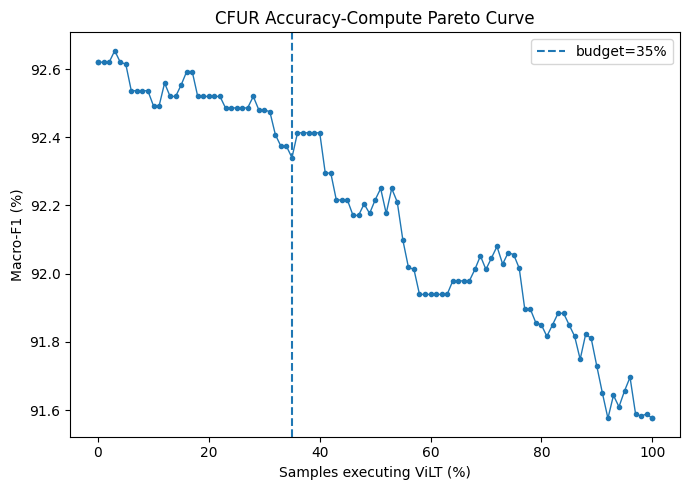

In [14]:
last = runs[-1]
p = (
    last["pareto_val"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["deep_rate", "macro_f1"])
)

plt.figure(figsize=(7, 5))
plt.plot(
    p["deep_rate"] * 100,
    p["macro_f1"] * 100,
    marker=".",
    linewidth=1
)
plt.axvline(
    TARGET_DEEP_RATE * 100,
    linestyle="--",
    label=f"budget={TARGET_DEEP_RATE:.0%}"
)
plt.xlabel("Samples executing ViLT (%)")
plt.ylabel("Macro-F1 (%)")
plt.title("CFUR Accuracy-Compute Pareto Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT_DIR / "cfur_pareto_curve.png",
    dpi=220
)
plt.show()

In [15]:
Yte, c_te, d_te, pu_te, final = last["test_arrays"]
pred_c = c_te.argmax(1)
pred_d = d_te.argmax(1)
pred_f = final.argmax(1)

def bootstrap_ci_metric(
    y, pred, metric_fn, n_boot=N_BOOT, seed=123
):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(y)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals.append(metric_fn(y[idx], pred[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

def bootstrap_paired_diff(
    y, pred_a, pred_b, metric_fn,
    n_boot=N_BOOT, seed=456
):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(y)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals.append(
            metric_fn(y[idx], pred_a[idx])
            - metric_fn(y[idx], pred_b[idx])
        )
    return np.percentile(vals, [2.5, 50, 97.5])

mf1 = lambda y, p: f1_score(y, p, average="macro")

ci_rows = []
for name, pred in [
    ("CLIP-cheap", pred_c),
    ("Always-deep", pred_d),
    ("CFUR", pred_f)
]:
    lo, med, hi = bootstrap_ci_metric(
        Yte, pred, mf1
    )
    ci_rows.append({
        "method": name,
        "metric": "macro_f1",
        "ci2.5": lo,
        "median": med,
        "ci97.5": hi
    })

for a, b, pa, pb in [
    ("CFUR", "CLIP-cheap", pred_f, pred_c),
    ("CFUR", "Always-deep", pred_f, pred_d)
]:
    lo, med, hi = bootstrap_paired_diff(
        Yte, pa, pb, mf1
    )
    ci_rows.append({
        "method": f"{a} minus {b}",
        "metric": "paired_macro_f1_difference",
        "ci2.5": lo,
        "median": med,
        "ci97.5": hi
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)
ci_df.to_csv(
    OUT_DIR / "bootstrap_95ci.csv",
    index=False
)

,method,metric,ci2.5,median,ci97.5
0,CLIP-cheap,macro_f1,0.903952,0.914011,0.924080
1,Always-deep,macro_f1,0.896645,0.908005,0.917110
2,CFUR,macro_f1,0.903919,0.913312,0.923677
3,CFUR minus CLIP-cheap,paired_macro_f1_difference,-0.002046,-0.000653,0.000514
4,CFUR minus Always-deep,paired_macro_f1_difference,-0.003013,0.005918,0.014943


In [16]:
ablation = metrics_all[
    metrics_all["method"].isin([
        "CFUR",
        "Uncertainty-routing",
        "Random-routing",
        "CLIP-cheap",
        "Always-deep-CLIP+ViLT"
    ])
].copy()

display(ablation)
ablation.to_csv(
    OUT_DIR / "ablation_matched_cost.csv",
    index=False
)

,seed,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,ece,roc_auc
0,13,CLIP-cheap,0.000000,0.934488,0.914209,0.906376,0.922963,0.263975,0.106248,0.045390,0.980654
1,13,Always-deep-CLIP+ViLT,1.000000,0.930157,0.907833,0.902847,0.913178,0.243361,0.117047,0.046732,0.974342
2,13,CFUR,0.027071,0.933947,0.913559,0.905500,0.922603,0.261034,0.106509,0.045103,0.980268
3,13,Uncertainty-routing,0.027071,0.938008,0.918620,0.911567,0.926396,0.277976,0.109348,0.049248,0.980246
4,13,Random-routing,0.027071,0.934218,0.913824,0.906120,0.922420,0.263588,0.106435,0.045348,0.980276


## Stage 3 — End-to-end conditional inference profiling

The next cell performs live inference on the same raw test subset and records:
- latency;
- throughput;
- peak CUDA memory;
- fraction of samples that actually execute ViLT.

This is the evidence needed to support a genuine resource-efficiency claim.

In [17]:
def make_cheap_tensor(t, v):
    cos = (t * v).sum(dim=1, keepdim=True)
    return torch.cat(
        [t, v, torch.abs(t-v), t*v, cos],
        dim=1
    )

def make_router_tensor(t, v, cheap_logits):
    p = F.softmax(cheap_logits, dim=1)
    maxp = p.max(dim=1, keepdim=True).values
    if p.shape[1] > 1:
        top2 = torch.topk(p, 2, dim=1).values
        margin = top2[:, 0:1] - top2[:, 1:2]
    else:
        margin = maxp
    ent = -(
        p.clamp_min(1e-9)
        * p.clamp_min(1e-9).log()
    ).sum(dim=1, keepdim=True)
    cos = (t * v).sum(dim=1, keepdim=True)
    return torch.cat(
        [t, v, torch.abs(t-v), cos, ent, maxp, margin],
        dim=1
    )

def profile_mode(
    mode, ds, trained,
    max_samples=256, batch_size=16
):
    assert mode in {"cheap", "always_deep", "cfur"}

    subset = torch.utils.data.Subset(
        ds, range(min(max_samples, len(ds)))
    )
    loader = DataLoader(
        subset, batch_size=batch_size,
        shuffle=False, collate_fn=raw_collate,
        num_workers=2, pin_memory=True
    )

    cheap = trained["cheap"].to(DEVICE).eval()
    deep = trained["deep"].to(DEVICE).eval()
    router = trained["router"].to(DEVICE).eval()
    mu, sd, tau = (
        trained["mu"], trained["sd"], trained["tau"]
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    gc.collect()
    cuda_sync()
    t0 = time.perf_counter()
    n = 0
    deep_n = 0

    with torch.inference_mode():
        for b in loader:
            cp = clip_processor(
                text=b["texts"],
                images=b["images"],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            )
            cp = {k: v.to(DEVICE) for k, v in cp.items()}

            _te_raw = clip_model.get_text_features(
                input_ids=cp["input_ids"],
                attention_mask=cp.get("attention_mask", None)
            )
            _ie_raw = clip_model.get_image_features(
                pixel_values=cp["pixel_values"]
            )
            # transformers>=5.0: get_text_features/get_image_features return a
            # BaseModelOutputWithPooling instead of a raw tensor -- unwrap via
            # .pooler_output, same fix as extract_clip_features above.
            _te_raw = _te_raw.pooler_output if hasattr(_te_raw, "pooler_output") else _te_raw
            _ie_raw = _ie_raw.pooler_output if hasattr(_ie_raw, "pooler_output") else _ie_raw
            te = F.normalize(_te_raw.float(), dim=-1)
            ie = F.normalize(_ie_raw.float(), dim=-1)
            clog = cheap(make_cheap_tensor(te, ie))

            if mode == "cheap":
                _ = clog
            else:
                if mode == "always_deep":
                    route = torch.ones(
                        len(b["texts"]),
                        dtype=torch.bool,
                        device=DEVICE
                    )
                else:
                    rf = make_router_tensor(te, ie, clog)
                    pu = router(rf) * sd + mu
                    route = pu > tau

                if route.any():
                    idx = (
                        route.nonzero(as_tuple=False)
                        .squeeze(1).cpu().tolist()
                    )
                    texts = [b["texts"][i] for i in idx]
                    images = [b["images"][i] for i in idx]

                    vp = vilt_processor(
                        images=images,
                        text=texts,
                        return_tensors="pt",
                        padding=True,
                        truncation=True,
                        max_length=40
                    )
                    vp = {
                        k: v.to(DEVICE)
                        for k, v in vp.items()
                    }
                    vo = vilt_model(**vp)
                    j = (
                        vo.pooler_output
                        if getattr(
                            vo, "pooler_output", None
                        ) is not None
                        else vo.last_hidden_state[:, 0]
                    )
                    _ = deep(
                        te[route], ie[route], j.float()
                    )
                    deep_n += int(route.sum())

            n += len(b["texts"])

    cuda_sync()
    sec = time.perf_counter() - t0
    peak = (
        torch.cuda.max_memory_allocated() / 1024**2
        if torch.cuda.is_available() else np.nan
    )

    return {
        "mode": mode,
        "samples": n,
        "deep_samples": deep_n,
        "deep_rate": deep_n / n if n else 0,
        "seconds": sec,
        "ms_per_sample": 1000 * sec / n,
        "samples_per_second": n / sec,
        "peak_vram_mb": peak
    }

profile_rows = []
for mode in ["cheap", "always_deep", "cfur"]:
    print("Profiling", mode)
    profile_rows.append(
        profile_mode(
            mode,
            datasets["test"],
            last,
            max_samples=256,
            batch_size=16
        )
    )

profile_df = pd.DataFrame(profile_rows)
display(profile_df)
profile_df.to_csv(
    OUT_DIR / "end_to_end_resource_profile.csv",
    index=False
)

Profiling cheap
Profiling always_deep
Profiling cfur


,mode,samples,deep_samples,deep_rate,seconds,ms_per_sample,samples_per_second,peak_vram_mb
0,cheap,256,0,0.000000,4.697284,18.348766,54.499577,1092.429199
1,always_deep,256,256,1.000000,11.527336,45.028655,22.208081,1366.908203
2,cfur,256,6,0.023438,5.028379,19.642106,50.911039,1101.404297


In [18]:
def param_count(model):
    return {
        "total_params": sum(
            p.numel() for p in model.parameters()
        ),
        "trainable_params": sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        )
    }

param_rows = []
for name, model in [
    ("CLIP backbone", clip_model),
    ("ViLT backbone", vilt_model),
    ("Cheap head", last["cheap"]),
    ("Deep interaction head", last["deep"]),
    ("Utility router", last["router"])
]:
    param_rows.append({
        "component": name,
        **param_count(model)
    })

params_df = pd.DataFrame(param_rows)
display(params_df)
params_df.to_csv(
    OUT_DIR / "parameter_counts.csv",
    index=False
)

,component,total_params,trainable_params
0,CLIP backbone,151277313,0
1,ViLT backbone,111595008,0
2,Cheap head,1116546,1116546
3,Deep interaction head,1380610,1380610
4,Utility router,411521,411521


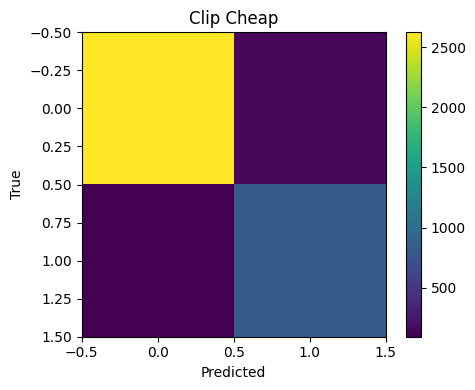

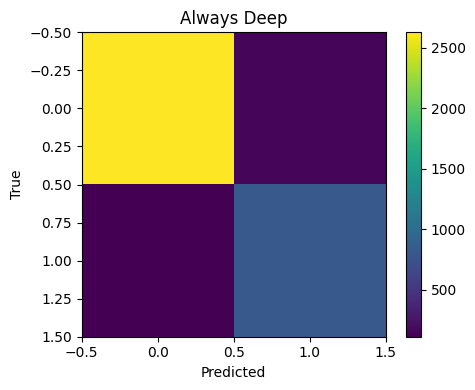

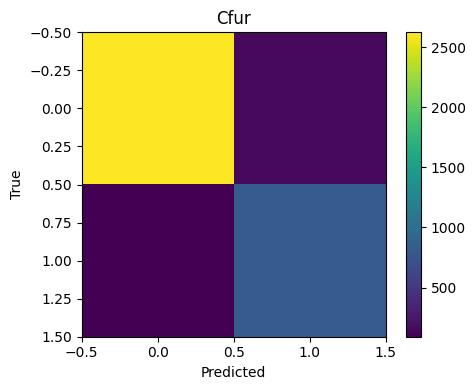

In [19]:
Yte, c_te, d_te, pu_te, final = last["test_arrays"]

for name, logits in [
    ("clip_cheap", c_te),
    ("always_deep", d_te),
    ("cfur", final)
]:
    cm = confusion_matrix(
        Yte, logits.argmax(1)
    )
    pd.DataFrame(cm).to_csv(
        OUT_DIR / f"confusion_matrix_{name}.csv",
        index=False
    )

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(name.replace("_", " ").title())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f"confusion_matrix_{name}.png",
        dpi=200
    )
    plt.show()

In [20]:
torch.save({
    "cheap_head": last["cheap"].state_dict(),
    "deep_head": last["deep"].state_dict(),
    "router": last["router"].state_dict(),
    "utility_mean": last["mu"],
    "utility_sd": last["sd"],
    "routing_threshold": last["tau"],
    "target_deep_rate": TARGET_DEEP_RATE,
    "clip_model": CLIP_NAME,
    "vilt_model": VILT_NAME,
    "num_classes": NUM_CLASSES,
    "label_classes": le.classes_.tolist()
}, OUT_DIR / "cfur_final_checkpoint.pt")

print("Saved outputs:")
for p in sorted(OUT_DIR.iterdir()):
    print("-", p.name)

Saved outputs:
- ablation_matched_cost.csv
- all_seed_metrics.csv
- bootstrap_95ci.csv
- cfur_final_checkpoint.pt
- cfur_pareto_curve.png
- confusion_matrix_always_deep.csv
- confusion_matrix_always_deep.png
- confusion_matrix_cfur.csv
- confusion_matrix_cfur.png
- confusion_matrix_clip_cheap.csv
- confusion_matrix_clip_cheap.png
- end_to_end_resource_profile.csv
- manuscript_summary_mean_sd.csv
- parameter_counts.csv
- resource_components.csv
- test_predictions.csv
- validation_pareto_all_seeds.csv


# Final manuscript run checklist

After the first successful run:

1. Set `FULL_PAPER_MODE=True`.
2. Remove sample caps.
3. Run Fakeddit **binary**.
4. Change `FAKEDDIT_LABEL_COL="6_way_label"` and rerun the fine-grained task.
5. Create a `manifest.csv` for the **full FakeNewsNet** and rerun exactly the same pipeline.
6. Add a third external benchmark if feasible.
7. Archive code, manifests, split definitions, raw per-sample predictions and result tables in GitHub + Zenodo.

### Generated outputs

- `manuscript_summary_mean_sd.csv`
- `validation_pareto_all_seeds.csv`
- `cfur_pareto_curve.png`
- `bootstrap_95ci.csv`
- `ablation_matched_cost.csv`
- `end_to_end_resource_profile.csv`
- `resource_components.csv`
- `parameter_counts.csv`
- `test_predictions.csv`
- confusion matrices
- `cfur_final_checkpoint.pt`

### Novelty wording

Do **not** position the contribution as simply “adaptive fusion.”

The intended contribution is:

> **Counterfactual fusion-utility routing:** predicting whether additional expensive multimodal reasoning will reduce the expected classification error for the current sample, and conditionally executing the heavy fusion branch under an explicit deployment budget.

Compare against cheap-only, always-deep, uncertainty routing at matched compute, random routing at matched compute, and relevant prior ambiguity/dynamic-fusion methods.